# Computer Exercise 4.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.2 Errors in Polynomial Interpolation — *세 가지 오차 표현과 그 예측력*
> **풀이 일자**: Day 104
> **언어**: Python 3 (NumPy · pandas · Matplotlib · mpmath)

P1 은 실축의 오차식이 **등식**이지만 상계로 바꾸면 Runge 함수에서 참인 수렴을 증명하지
못한다는 것을 보였다. P2 는 그 오차의 계수가 나눗셈차분 $f[x_0,\dots,x_n,x]$ 이고, 그것이
단체 위의 도함수 평균이라는 것을 보였다. **P3 는 같은 나눗셈차분을 복소평면의 등고선적분으로
다시 쓴다** — 그러면 Day 103 P3 가 *측정만* 했던 $\rho=1.2198$ 이 **유도**된다.
덤으로, 나눗셈차분을 실제로 계산할 때의 **절점 순서** 문제 (Leja 순서) 를 잰다.

## 1. 문제 (원문)

> **Computer Exercise 4.2.3.** (a) The Newton form of the interpolating polynomial depends on the
> *ordering* of the nodes, even though the polynomial itself does not. Implement the **Leja
> ordering** (choose $x_0$ to maximize $|x|$, and thereafter $x_k$ to maximize
> $\prod_{j<k}|x_k-x_j|$) and compare it with the natural, reversed, and random orderings: report
> the size of the divided-difference coefficients, the amount of cancellation in the nested
> (Horner) evaluation, and the resulting forward error against a high-precision reference.
> (b) Verify numerically the three equivalent forms of the interpolation error,
> $$f(x)-p_n(x)=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}\omega(x)
> = f[x_0,\dots,x_n,x]\,\omega(x)
> = \frac{1}{2\pi i}\oint_\Gamma \frac{\omega(x)}{\omega(z)}\,\frac{f(z)}{z-x}\,dz ,$$
> the last (Hermite's formula) valid when $f$ is analytic inside a contour $\Gamma$ enclosing $x$
> and all nodes. (c) Use the third form together with the Day-103 result
> $\min_{\text{nodes}}\|\omega\|_\infty=2^{-n}$ to **derive** the geometric convergence rate for
> $f(x)=1/(1+25x^2)$ on $[-1,1]$ with Chebyshev nodes, and compare with the measured rate.
> Explain why the first form cannot give this result.

### 한국어 풀이용 정리

오차의 세 표현은 **수학적으로 동치**지만 **예측력이 전혀 다르다**.

| | 요구 조건 | 계산 가능? | Runge · Chebyshev 에서 |
|---|---|---|---|
| (A) $\dfrac{f^{(n+1)}(\xi_x)}{(n+1)!}\omega(x)$ | $f\in C^{n+1}$ | $\xi_x$ 를 모르면 상계로만 | 상계가 $(5/2)^n$ 로 **발산** |
| (B) $f[x_0,\dots,x_n,x]\,\omega(x)$ | 없음 (대수적) | **예** (정확) | 항등식 — 예측이 아니라 재기술 |
| (C) $\dfrac{1}{2\pi i}\displaystyle\oint_\Gamma \dfrac{\omega(x)}{\omega(z)}\dfrac{f(z)}{z-x}dz$ | $f$ 해석적 | **예** (수치적분) | $\rho^{-n}$ 로 **수렴**, $\rho=\tfrac{1+\sqrt{26}}5$ |

(A) 가 실패하는 이유는 명확하다: $\|f^{(n+1)}\|_\infty$ 를 **실축에서** 최대화하는데,
$1/(1+25x^2)$ 의 도함수는 $x=0$ 에서 $(n+1)!\,5^{n+1}$ 로 폭발한다. $\|\omega\|=2^{-n}$ 의 이득
$2^{-n}$ 을 $5^{n+1}$ 이 집어삼켜 상계가 $(5/2)^n$ 로 발산한다 — **실제 오차는 수렴하는데도.**
(C) 는 $f$ 를 실축이 아니라 **특이점을 피해 지나가는 타원** 위에서 평가하므로 그 폭발을 겪지
않는다.

한편 (B) 는 계산 가능하지만 **계산 방법에 순서 의존성**이 있다. 다항식은 절점 순서에 무관하나
Newton 형식의 계수 $f[x_0,\dots,x_k]$ 는 순서에 의존하고, 부동소수점에서는 그 차이가 실제
오차로 나타난다. (a) 는 그 문제를 다룬다.

## 2. 수학적 배경

### 2.1 Hermite 의 등고선 공식

$f$ 가 단순폐곡선 $\Gamma$ 의 내부와 그 위에서 해석적이고 $x$ 와 모든 절점이 $\Gamma$ 내부에
있으면, Cauchy 적분공식에서 출발해

$$\boxed{\;f[x_0,\dots,x_n]=\frac{1}{2\pi i}\oint_\Gamma\frac{f(z)}{\omega(z)}\,dz,\qquad
f(x)-p_n(x)=\frac{1}{2\pi i}\oint_\Gamma\frac{\omega(x)}{\omega(z)}\,\frac{f(z)}{z-x}\,dz.\;}$$

*스케치.* $\dfrac{f(z)}{\omega(z)}$ 의 극점은 절점들이고 유수는 $\dfrac{f(x_i)}{\omega'(x_i)}$ 이므로
첫 식은 Lagrange 형식의 최고차 계수 표현과 같다. 두 번째 식은 피적분함수의 극점이
$x_0,\dots,x_n$ 과 $x$ 이고, $z=x$ 에서의 유수가 $f(x)$, $z=x_i$ 에서의 유수 합이 $-p_n(x)$ 임을
쓰면 나온다.

### 2.2 Bernstein 타원과 수렴률

$[-1,1]$ 에 대한 **Bernstein 타원** $E_R$ ($R>1$) 은
$$z(\theta)=\tfrac12\big(Re^{i\theta}+R^{-1}e^{-i\theta}\big),\qquad \theta\in[0,2\pi),$$
즉 초점이 $\pm1$ 이고 반축 합이 $R$ 인 타원이다. $f$ 가 $E_R$ 내부에서 해석적이라 하자.

Chebyshev 근 절점에서는 $\omega(z)=2^{-n}T_{n+1}(z)$ 이고, $E_R$ 위에서
$|T_{n+1}(z)|=\tfrac12|R^{n+1}e^{i(n+1)\theta}+R^{-(n+1)}e^{-i(n+1)\theta}|\ \gtrsim\ \tfrac12(R^{n+1}-R^{-(n+1)})$.
따라서 $[-1,1]$ 위에서 $\|\omega\|_\infty=2^{-n}$ 이므로

$$\left|\frac{\omega(x)}{\omega(z)}\right|\;\lesssim\;\frac{2^{-n}}{2^{-n}\cdot\tfrac12 R^{n+1}}
=\frac{2}{R^{n+1}}
\quad\Longrightarrow\quad
\boxed{\;\|f-p_n\|_\infty\;\le\;\frac{C(R)}{R^{n}}\;}$$

$R$ 을 $f$ 가 해석적인 최대 타원까지 밀면 최적 수렴률을 얻는다.

**Runge 함수.** $f(z)=1/(1+25z^2)$ 의 극점은 $z=\pm i/5$. $z=iy$ 가 $E_R$ 위에 있으려면
$y=\tfrac12(R-R^{-1})$ 이므로 $R-R^{-1}=2/5$, 즉

$$\rho=\frac{1+\sqrt{26}}{5}=1.2198039\ldots$$

$R<\rho$ 인 모든 타원이 허용되므로 수렴률은 $\rho^{-n}$ 이다 — **Day 103 P3 가 측정한 값**
($1.218007$, 상대차 $0.147\%$) 이 여기서 유도된다.

### 2.3 첫 번째 표현이 실패하는 이유 (정량적으로)

부분분수 $\dfrac{1}{1+25x^2}=\dfrac12\left[\dfrac{1}{1-5ix}+\dfrac{1}{1+5ix}\right]$ 에서

$$f^{(m)}(x)=m!\;\mathrm{Re}\!\left[\frac{(5i)^m}{(1-5ix)^{m+1}}\right],
\qquad \|f^{(m)}\|_{\infty,[-1,1]}\sim m!\,5^{m}\ \ (x=0 \text{ 에서}).$$

따라서 최적 절점 ($\|\omega\|=2^{-n}$) 에서도

$$\frac{\|f^{(n+1)}\|_\infty}{(n+1)!}\|\omega\|_\infty \;\sim\; 5^{n+1}\cdot 2^{-n}=5\left(\frac52\right)^{n}
\;\xrightarrow[n\to\infty]{}\;\infty .$$

**상계는 $2.5^n$ 로 발산하고 실제 오차는 $1.2198^{-n}$ 로 수렴한다.** 두 배율의 곱이
$n=40$ 에서 $10^{19}$ 를 넘는다. 이것이 "상계가 헐겁다" 의 극단적인 예이며, 원인은
$f^{(n+1)}$ 을 **실축에서** 최대화한 데 있다.

### 2.4 Newton 형식과 절점 순서 (Leja)

$p_n$ 은 절점 순서에 무관하지만 Newton 계수 $c_k=f[x_0,\dots,x_k]$ 는 순서에 의존한다.
중첩곱 평가
$$p_n(x)=c_0+(x-x_0)\big(c_1+(x-x_1)(\cdots)\big)$$
의 **후방안정성**은 부분곱 $\prod_{j<k}|x-x_j|$ 이 $k$ 에 대해 단조로울 때 좋아진다.
**Leja 순서**는 이를 그리디하게 강제한다:

$$|x_0|=\max_i|x_i|,\qquad
\prod_{j<k}|x_k-x_j|=\max_{i}\prod_{j<k}|x_i-x_j| \quad (k=1,\dots,n).$$

Reichel (1990) · Higham (2004) 이 이 순서에서 Newton 형식의 오차가 크게 줄어듦을 보였다.
셀 [1]·[2] 에서 순서별로 (i) $\max_k|c_k|$, (ii) 중첩곱 도중의 **소거비**
$\max_k|s_k|/|s_{\rm final}|$, (iii) 고정밀 참값에 대한 **전방오차**를 잰다.

## 3. 풀이 흐름

1. **순서 6 종 구현** — natural / reversed / random×2 / **Leja** / bit-reversal (van der Corput).
   두 절점족 (등간격, Chebyshev), $n=20,40$, 두 함수 ($e^{x}$, Runge) 에 적용.
2. **순서별 진단** — Newton 계수의 최대 크기, 중첩곱의 소거비, mpmath 60 자리 참값에 대한
   전방오차. 다항식 자체는 순서에 무관하므로 참값은 **한 번만** 계산한다.
3. **세 표현의 수치 대조** — Runge, Chebyshev 절점, $x=0.3$ 고정, $n=10,\dots,40$:
   (A) 상계 (닫힌 형태 $\|f^{(n+1)}\|$ 사용), (B) 나눗셈차분 항등식 (mpmath),
   (C) Bernstein 타원 위의 사다리꼴 등고선적분. (B)·(C) 는 실제 오차와 **일치해야** 하고
   (A) 는 상계여야 한다.
4. **따름정리 1** — $\min\|\omega\|=2^{-n}$ 을 (A) 에 넣어 $f=e^{x}$ 의 상계
   $e/(2^n(n+1)!)$ 를 얻고 실측과 비교 (mpmath). 여기서는 (A) 가 잘 작동한다 — 왜인지 대조군.
5. **따름정리 2** — Runge 에서 (A) 상계의 발산율 $2.5^n$ 과 (C) 상계의 수렴율 $\rho^{-n}$ 를
   회귀로 재고, $\rho$ 의 닫힌 형태 $(1+\sqrt{26})/5$ 및 Day 103 P3 의 측정값과 대조.
   최적 타원 반경 $R^\star$ 를 수치최적화로 찾아 $\rho$ 에 수렴하는지 확인.
6. **시각화** — (a) 순서별 전방오차, (b) 세 표현의 $n$ 의존성, (c) 복소평면의 타원·극점·절점,
   (d) 타원 반경에 대한 (C) 상계.
7. **해석**.

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  절점 순서 6 종 —  Leja 를 포함해
# ══════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mpmath as mp
from math import factorial

mp.mp.dps = 60
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(104003)

def cheb_roots(m, a=-1.0, b=1.0):
    k = np.arange(m)
    return np.sort((a+b)/2 + (b-a)/2*np.cos((2*k+1)*np.pi/(2*m)))

def leja_order(xs):
    """그리디 Leja 순서:  |x_0| 최대,  이후 prod_{j<k}|x_k-x_j| 최대."""
    xs = list(np.asarray(xs, float)); out = []
    i0 = int(np.argmax(np.abs(xs))); out.append(xs.pop(i0))
    while xs:
        prods = [np.prod([abs(c-o) for o in out]) for c in xs]
        i = int(np.argmax(prods)); out.append(xs.pop(i))
    return np.array(out)

def bitrev_order(xs):
    """van der Corput / bit-reversal 순서 (Leja 의 값싼 근사)."""
    m = len(xs); idx = sorted(range(m), key=lambda i: float(
        sum(((i >> b) & 1)*2.0**(-b-1) for b in range(20))))
    return np.asarray(xs, float)[idx]

def orderings(xs, rng):
    xs = np.asarray(xs, float)
    r1 = xs.copy(); rng.shuffle(r1)
    r2 = xs.copy(); rng.shuffle(r2)
    return {"natural": xs, "reversed": xs[::-1], "random-1": r1, "random-2": r2,
            "bit-reversal": bitrev_order(xs), "Leja": leja_order(xs)}

def divdiff(z, y):
    n = len(z); T = list(y); c = [T[0]]
    for k in range(1, n):
        T = [(T[i+1]-T[i])/(z[i+k]-z[i]) for i in range(n-k)]
        c.append(T[0])
    return c

def horner_with_trace(z, c, xq):
    """중첩곱 평가와 도중 부분값의 최대 절대값 (소거 진단)."""
    xq = np.asarray(xq, float)
    s = np.full_like(xq, float(c[-1])); mx = np.abs(s).copy()
    for k in range(len(c)-2, -1, -1):
        s = s*(xq - z[k]) + c[k]
        mx = np.maximum(mx, np.abs(s))
    return s, mx

FUNS = {"exp(x)": (np.exp, mp.exp),
        "Runge":  (lambda x: 1/(1+25*x**2), lambda z: 1/(1+25*z**2))}
FAMS  = {"equispaced": lambda m: np.linspace(-1, 1, m),
         "Chebyshev":  lambda m: cheb_roots(m)}
GRID  = np.linspace(-1, 1, 201)

# 고정밀 참값 (순서 무관) —  무게중심 형식으로
def _tompf(v):
    return v if isinstance(v, mp.mpf) else mp.mpf(float(v))

def bary_mp(xs, ys, xq):
    """무게중심 제2형 (고정밀).  평가점을 float 로 반올림하지 않는다 —
    그렇게 하면 |x - fl(x)|*|f'| ~ 1e-17 의 인공 바닥이 생긴다."""
    xs = [_tompf(t) for t in xs]; n = len(xs)
    w = []
    for i in range(n):
        p = mp.mpf(1)
        for j in range(n):
            if j != i: p *= (xs[i]-xs[j])
        w.append(1/p)
    out = []
    for x in xq:
        x = _tompf(x); num = den = mp.mpf(0); hit = None
        for i in range(n):
            if x == xs[i]: hit = ys[i]; break
            t = w[i]/(x-xs[i]); num += t*ys[i]; den += t
        out.append(hit if hit is not None else num/den)
    return out

rows = []
for fname, (fnp, fmp) in FUNS.items():
    for famname, gen in FAMS.items():
        for n in (20, 40):
            xs = gen(n+1)
            ref = bary_mp(xs, [fmp(mp.mpf(float(t))) for t in xs], GRID)
            for oname, zo in orderings(xs, rng).items():
                c = divdiff(list(zo), [fnp(t) for t in zo])
                val, mx = horner_with_trace(list(zo), c, GRID)
                fe = max(abs(float(v) - float(r)) for v, r in zip(val, ref))
                # 순서 의존 지표: 중첩곱의 항 크기  max_k |c_k| * max_x prod_{j<k}|x-x_j|
                pk = np.ones_like(GRID); term = 0.0
                for k in range(len(c)):
                    term = max(term, abs(c[k])*float(np.max(pk)))
                    pk = pk*np.abs(GRID - zo[k])
                rows.append(dict(f=fname, nodes=famname, n=n, order=oname,
                                 max_coef=max(abs(v) for v in c), max_term=term,
                                 cancel=float(np.max(mx/np.maximum(np.abs(val), 1e-300))),
                                 fwd_err=fe))
df1 = pd.DataFrame(rows)
print("[a]  Newton 계수의 최대 크기  max_k |f[x_0..x_k]|")
print(df1.pivot_table(index=["f","nodes","n"], columns="order", values="max_coef")
        .to_string(float_format=lambda v: f"{v:.3e}"))
print("\n  * Runge 행에서 값이 순서와 무관하게 같은 것은 우연이 아니다: 최고차 계수")
print("    f[x_0..x_n] 은 순서에 **무관**하고, Runge 에서는 그것이 다른 모든 c_k 를 압도한다.")
print("    따라서 max_k|c_k| 는 순서 진단으로 쓸 수 없다.  아래의 항 크기를 쓴다.")
print("\n[a2]  중첩곱 항의 최대 크기   max_k |c_k| * max_x prod_{j<k}|x - x_j|")
print(df1.pivot_table(index=["f","nodes","n"], columns="order", values="max_term")
        .to_string(float_format=lambda v: f"{v:.3e}"))


[a]  Newton 계수의 최대 크기  max_k |f[x_0..x_k]|
order                     Leja  bit-reversal   natural  random-1  random-2  reversed
f      nodes      n                                                                 
Runge  Chebyshev  20 6.467e+03     6.467e+03 6.467e+03 6.467e+03 6.467e+03 6.467e+03
                  40 1.275e+08     1.275e+08 1.275e+08 1.275e+08 1.275e+08 1.275e+08
       equispaced 20 2.602e+05     2.602e+05 2.602e+05 2.602e+05 2.602e+05 2.602e+05
                  40 3.536e+11     3.536e+11 3.536e+11 3.536e+11 3.536e+11 3.536e+11
exp(x) Chebyshev  20 1.174e+00     1.021e+00 3.730e-01 1.760e+00 1.974e+00 2.711e+00
                  40 1.175e+00     1.029e+00 3.692e-01 1.778e+00 1.080e+00 2.716e+00
       equispaced 20 1.175e+00     9.089e-01 3.869e-01 2.226e+00 1.000e+00 2.718e+00
                  40 1.175e+00     9.089e-01 3.772e-01 9.561e-01 1.160e+00 2.718e+00

  * Runge 행에서 값이 순서와 무관하게 같은 것은 우연이 아니다: 최고차 계수
    f[x_0..x_n] 은 순서에 **무관**하고, Runge 에서는 그것이 다른 모든 c_k 를 

In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  순서별 소거비와 전방오차
# ══════════════════════════════════════════════════════════════════════════
print("[b]  중첩곱 도중의 소거비   max_k |s_k| / |s_final|   (1 이면 소거 없음)")
print(df1.pivot_table(index=["f","nodes","n"], columns="order", values="cancel")
        .to_string(float_format=lambda v: f"{v:.3e}"))

print("\n[c]  고정밀 참값(60 자리) 대비 전방오차  max_x |p_float64(x) - p_exact(x)|")
piv = df1.pivot_table(index=["f","nodes","n"], columns="order", values="fwd_err")
print(piv.to_string(float_format=lambda v: f"{v:.3e}"))

print("\n[d]  각 행에서 최선/최악 순서와 그 비")
best = piv.idxmin(axis=1); worst = piv.idxmax(axis=1)
summary = pd.DataFrame({
    "best": best, "best_err": piv.min(axis=1),
    "worst": worst, "worst_err": piv.max(axis=1),
    "worst/best": piv.max(axis=1)/piv.min(axis=1),
    "Leja/best": piv["Leja"]/piv.min(axis=1),
    "natural/Leja": piv["natural"]/piv["Leja"]})
print(summary.to_string(float_format=lambda v: f"{v:.4g}"))
print("\n  Leja 가 최선인 행의 수:", int((best == "Leja").sum()), "/", len(best))
print("  natural 대비 Leja 의 개선 배수 (기하평균):",
      f"{np.exp(np.mean(np.log(summary['natural/Leja']))):.3f}")
print("  최악/최선 비의 최대:", f"{summary['worst/best'].max():.3e}",
      " → 같은 다항식인데 순서만 바꿔도 이만큼 달라진다.")


[b]  중첩곱 도중의 소거비   max_k |s_k| / |s_final|   (1 이면 소거 없음)
order                     Leja  bit-reversal   natural  random-1  random-2  reversed
f      nodes      n                                                                 
Runge  Chebyshev  20 3.150e+05     3.977e+05 2.512e+07 5.332e+05 3.015e+05 2.512e+07
                  40 3.718e+09     8.711e+09 5.144e+13 5.771e+09 1.902e+10 5.144e+13
       equispaced 20 2.522e+07     2.522e+07 4.361e+08 5.322e+07 4.440e+07 4.361e+08
                  40 5.258e+13     5.258e+13 2.827e+16 8.044e+13 9.885e+13 2.827e+16
exp(x) Chebyshev  20 1.097e+00     1.001e+00 1.001e+00 1.876e+00 2.599e+00 3.189e+00
                  40 1.097e+00     1.001e+00 1.000e+00 2.433e+00 1.797e+00 3.193e+00
       equispaced 20 1.097e+00     1.000e+00 1.000e+00 2.805e+00 1.718e+00 3.195e+00
                  40 1.097e+00     4.236e+00 1.135e+03 2.722e+01 1.494e+00 1.847e+02

[c]  고정밀 참값(60 자리) 대비 전방오차  max_x |p_float64(x) - p_exact(x)|
order                     Lej

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  오차의 세 표현 (A) (B) (C) 를 같은 자리에서 비교
# ══════════════════════════════════════════════════════════════════════════
RHO = (1 + np.sqrt(26))/5                     # Runge 의 Bernstein 타원 파라미터
print(f"Runge 의 최대 Bernstein 반경  rho = (1+sqrt26)/5 = {RHO:.10f}")

def runge_deriv_max(m):
    """||f^{(m)}||_inf on [-1,1] :  f^{(m)}(x) = m! Re[(5i)^m/(1-5ix)^{m+1}],  최대는 x=0."""
    xs = np.linspace(-1, 1, 4001)
    v = np.abs((5j)**m/(1-5j*xs)**(m+1))
    return float(np.max(v))                    # m! 은 따로 곱한다 (로그로 다루기 위해)

def contour_error(xs_nodes, x, R, M=4096):
    """Hermite 공식으로 f(x)-p_n(x) 를 직접 적분 (Runge)."""
    th = 2*np.pi*np.arange(M)/M
    z  = 0.5*(R*np.exp(1j*th) + np.exp(-1j*th)/R)
    dz = 0.5j*(R*np.exp(1j*th) - np.exp(-1j*th)/R)
    wz = np.ones_like(z)
    for t in xs_nodes: wz *= (z - t)
    wx = np.prod(x - np.asarray(xs_nodes))
    fz = 1/(1+25*z**2)
    integ = (wx/wz)*fz/(z - x)
    return np.sum(integ*dz)*(2*np.pi/M)/(2j*np.pi)

def contour_bound(xs_nodes, R, M=4096):
    """sup_x |omega(x)| * max|f(z)/omega(z)/(z-x)| * L/(2pi) 형태의 상계."""
    th = 2*np.pi*np.arange(M)/M
    z  = 0.5*(R*np.exp(1j*th) + np.exp(-1j*th)/R)
    dz = 0.5*np.abs(R*np.exp(1j*th) - np.exp(-1j*th)/R)
    wz = np.ones_like(z)
    for t in xs_nodes: wz *= (z - t)
    g  = np.linspace(-1, 1, 2001)
    wg = np.ones_like(g)
    for t in xs_nodes: wg *= (g - t)
    wmax = np.max(np.abs(wg))
    dist = np.min(np.abs(z[:,None] - g[None,:]), axis=1)
    fz   = np.abs(1/(1+25*z**2))
    L    = np.sum(dz)*(2*np.pi/M)
    return wmax*np.max(fz/(np.abs(wz)*dist))*L/(2*np.pi)

x_probe = 0.3
rows = []
for n in (10, 14, 20, 26, 32, 40):
    xs = cheb_roots(n+1)
    # 실제 오차 (mpmath 참값)
    ys = [1/(1+25*mp.mpf(float(t))**2) for t in xs]
    p_mp = bary_mp(xs, ys, [x_probe])[0]
    err_true = float(1/(1+25*mp.mpf(x_probe)**2) - p_mp)
    # (B) 나눗셈차분 항등식
    zz = list(xs) + [x_probe]
    c_mp = None
    zmp = [mp.mpf(float(t)) for t in zz]
    ymp = [1/(1+25*t**2) for t in zmp]
    T = list(ymp)
    for k in range(1, len(zmp)):
        T = [(T[i+1]-T[i])/(zmp[i+k]-zmp[i]) for i in range(len(zmp)-k)]
    dd = T[0]
    wx = mp.mpf(1)
    for t in xs: wx *= (mp.mpf(x_probe) - mp.mpf(float(t)))
    err_B = float(dd*wx)
    # (C) 등고선적분
    err_C = contour_error(xs, x_probe, 0.98*RHO)
    # (A) 상계  ||f^{(n+1)}||/(n+1)! * ||omega||
    g = np.linspace(-1, 1, 4001); wg = np.ones_like(g)
    for t in xs: wg *= (g - t)
    boundA = runge_deriv_max(n+1)*np.max(np.abs(wg))     # (n+1)! 이 분자·분모에서 상쇄
    boundC = contour_bound(xs, 0.98*RHO)
    rows.append(dict(n=n, err_true=err_true, err_B=err_B, err_C=err_C.real,
                     relB=abs(err_B-err_true)/abs(err_true),
                     relC=abs(err_C.real-err_true)/abs(err_true),
                     boundA=boundA, boundC=boundC))
df3 = pd.DataFrame(rows)
print(f"\n[e]  Runge, Chebyshev 절점, x = {x_probe}  —  세 표현")
print(df3[["n","err_true","err_B","err_C","relB","relC"]]
        .to_string(index=False, float_format=lambda v: f"{v:.6g}"))
print(f"\n  (B) 의 최대 상대편차: {df3.relB.max():.2e}   (항등식 — 기계정밀도여야 한다)")
print(f"  (C) 의 최대 상대편차: {df3.relC.max():.2e}   (사다리꼴 등고선적분 — 지수수렴)")
print("\n[f]  상계  (A) 실축 도함수  vs  (C) 타원")
print(df3[["n","err_true","boundA","boundC"]]
        .to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("\n  (A)/|err| :", "  ".join(f"{v:.2e}" for v in (df3.boundA/df3.err_true.abs())))
print("  (C)/|err| :", "  ".join(f"{v:.2e}" for v in (df3.boundC/df3.err_true.abs())))


Runge 의 최대 Bernstein 반경  rho = (1+sqrt26)/5 = 1.2198039027



[e]  Runge, Chebyshev 절점, x = 0.3  —  세 표현
 n    err_true       err_B       err_C  relB        relC
10   0.0219102   0.0219102   0.0219102     0           0
14   0.0465174   0.0465174   0.0465174     0 2.98335e-16
20 -0.00163811 -0.00163811 -0.00163811     0 2.64744e-16
26 -0.00402277 -0.00402277 -0.00402277     0 2.15613e-16
32  0.00077257  0.00077257  0.00077257     0 1.40337e-16
40 1.97705e-05 1.97705e-05 1.97705e-05     0 1.71373e-16

  (B) 의 최대 상대편차: 0.00e+00   (항등식 — 기계정밀도여야 한다)
  (C) 의 최대 상대편차: 2.98e-16   (사다리꼴 등고선적분 — 지수수렴)

[f]  상계  (A) 실축 도함수  vs  (C) 타원
 n  err_true    boundA  boundC
10   0.02191 4.768e+04   5.511
14   0.04652 1.863e+06   2.658
20 -0.001638 4.547e+08  0.9071
26 -0.004023  1.11e+11  0.3107
32 0.0007726 2.711e+13  0.1065
40 1.977e-05 4.136e+16 0.02553

  (A)/|err| : 2.18e+06  4.00e+07  2.78e+11  2.76e+13  3.51e+16  2.09e+21
  (C)/|err| : 2.52e+02  5.71e+01  5.54e+02  7.72e+01  1.38e+02  1.29e+03


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  따름정리 1 —  min||omega|| = 2^{-n} 을 (A) 에 넣으면?   (대조군: f = e^x)
# ══════════════════════════════════════════════════════════════════════════
# f = e^x 는 전해석함수이므로 (A) 가 잘 작동한다.  Runge 와의 차이를 드러내기 위한 대조군.
mp.mp.dps = 80
rows = []
gq = [mp.mpf(k)/100 - 1 for k in range(201)]
for n in (4, 8, 12, 16, 20, 24):
    xs = cheb_roots(n+1)
    ys = [mp.exp(mp.mpf(float(t))) for t in xs]
    errs = [abs(mp.exp(g) - v) for g, v in zip(gq, bary_mp(xs, ys, gq))]
    err = float(max(errs))
    bound = float(mp.e/(mp.mpf(2)**n * mp.factorial(n+1)))   # ||f^{(n+1)}||=e, ||omega||=2^{-n}
    rows.append(dict(n=n, err=err, bound_2n=bound, ratio=bound/err))
mp.mp.dps = 60
df4 = pd.DataFrame(rows)
print("[g]  f = e^x on [-1,1], Chebyshev 절점")
print("     (A) 상계 =  ||f^{(n+1)}||_inf / (n+1)!  *  2^{-n}  =  e / (2^n (n+1)!)")
print(df4.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
print(f"\n  상계/실제 의 범위: {df4.ratio.min():.3f} ~ {df4.ratio.max():.3f}")
print("  → 전해석함수에서는 (A) 가 유용하다.  ||f^{(m)}|| 가 m 에 대해 유계이기 때문.")

# Runge 에서 같은 양을 계산하면?
print("\n[h]  같은 상계를 Runge 에 적용하면 (||f^{(n+1)}|| = (n+1)! * 5^{n+1} 규모)")
rows = []
for n in (4, 8, 12, 16, 20, 24, 32, 40):
    dm = runge_deriv_max(n+1)                       # (n+1)! 제외한 부분
    bound = dm * 2.0**(-n)                          # (n+1)! 상쇄
    rows.append(dict(n=n, deriv_factor=dm, bound=bound,
                     ratio_to_5=dm/5.0**(n+1)))
df4b = pd.DataFrame(rows)
print(df4b.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
sl = np.polyfit(df4b.n, np.log(df4b.bound), 1)[0]
print(f"\n  log(bound) 의 n 에 대한 기울기 = {sl:.6f}   ->  발산율 {np.exp(sl):.6f}")
print(f"  이론 예측 5/2 = 2.5  (||f^{{(n+1)}}||/(n+1)! ~ 5^{{n+1}},  ||omega|| = 2^{{-n}})")
print(f"  |f^{{(m)}}|/m! 이 정확히 5^m 인지: 비율 = {df4b.ratio_to_5.min():.6f} ~ {df4b.ratio_to_5.max():.6f}")


[g]  f = e^x on [-1,1], Chebyshev 절점
     (A) 상계 =  ||f^{(n+1)}||_inf / (n+1)!  *  2^{-n}  =  e / (2^n (n+1)!)
 n         err    bound_2n   ratio
 4 0.000639699  0.00141577 2.21318
 8 1.21901e-08 2.92612e-08 2.40041
12  4.2858e-14 1.06575e-13 2.48669
16 4.59792e-20 1.16613e-19 2.53621
20 1.97563e-26   5.074e-26  2.5683
24 4.03178e-33 1.04455e-32 2.59079

  상계/실제 의 범위: 2.213 ~ 2.591
  → 전해석함수에서는 (A) 가 유용하다.  ||f^{(m)}|| 가 m 에 대해 유계이기 때문.

[h]  같은 상계를 Runge 에 적용하면 (||f^{(n+1)}|| = (n+1)! * 5^{n+1} 규모)
 n  deriv_factor       bound  ratio_to_5
 4          3125     195.312           1
 8   1.95312e+06     7629.39           1
12    1.2207e+09      298023           1
16   7.62939e+11 1.16415e+07           1
20   4.76837e+14 4.54747e+08           1
24   2.98023e+17 1.77636e+10           1
32   1.16415e+23 2.71051e+13           1
40   4.54747e+28  4.1359e+16           1

  log(bound) 의 n 에 대한 기울기 = 0.916291   ->  발산율 2.500000
  이론 예측 5/2 = 2.5  (||f^{(n+1)}||/(n+1)! ~ 5^{n+1},  ||omega|| = 2^{-

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  따름정리 2 —  (C) 로부터 rho^{-n} 을 유도하고 측정과 대조
# ══════════════════════════════════════════════════════════════════════════
NS = np.array([10, 14, 20, 26, 32, 40, 50, 60])
errs, boundsC = [], []
mp.mp.dps = 60
gq2 = [mp.mpf(k)/300 - 1 for k in range(601)]
for n in NS:
    xs = cheb_roots(n+1)
    ys = [1/(1+25*mp.mpf(float(t))**2) for t in xs]
    vals = bary_mp(xs, ys, gq2)
    errs.append(float(max(abs(1/(1+25*g**2) - v) for g, v in zip(gq2, vals))))
    boundsC.append(contour_bound(xs, 0.98*RHO))
errs = np.array(errs); boundsC = np.array(boundsC)

A = np.polyfit(NS, np.log(errs), 1)
B = np.polyfit(NS, np.log(boundsC), 1)
rho_meas  = np.exp(-A[0])
rho_bound = np.exp(-B[0])
print("[i]  Runge, Chebyshev 절점 —  실제 최대오차와 (C) 상계의 지수감쇠")
print(pd.DataFrame(dict(n=NS, err_max=errs, boundC=boundsC,
                        ratio=boundsC/errs)).to_string(index=False,
      float_format=lambda v: f"{v:.5g}"))
print(f"\n  실측 감쇠율   rho_meas  = {rho_meas:.7f}")
print(f"  (C) 상계 감쇠율 rho_bound = {rho_bound:.7f}   (타원 R = 0.98 rho 로 고정했으므로"
      f" 0.98*rho = {0.98*RHO:.7f} 이 나와야 한다)")
print(f"  이론 (Bernstein)         = {RHO:.7f}")
print(f"  실측 대 이론 상대차: {abs(rho_meas-RHO)/RHO*100:.4f} %")
print(f"  Day 103 P3 의 측정값 1.218007 대비: {abs(rho_meas-1.218007)/1.218007*100:.4f} %")
r2 = 1 - np.sum((np.log(errs)-np.polyval(A, NS))**2)/np.sum((np.log(errs)-np.mean(np.log(errs)))**2)
print(f"  지수적합 R^2 = {r2:.6f}")

# 최적 타원 반경 —  R 을 바꿔가며 (C) 상계를 최소화
print("\n[j]  타원 반경 R 에 대한 (C) 상계  (n = 40)")
xs40 = cheb_roots(41)
Rs = np.linspace(1.02, RHO*0.999, 25)
bs = np.array([contour_bound(xs40, R) for R in Rs])
k  = int(np.argmin(bs))
print(pd.DataFrame(dict(R=Rs, bound=bs)).iloc[::3]
        .to_string(index=False, float_format=lambda v: f"{v:.5g}"))
print(f"\n  최소를 주는 R* = {Rs[k]:.6f}   (탐색 상한 {Rs[-1]:.6f} = 0.999 rho)")
print(f"  실제 오차 = {errs[list(NS).index(40)]:.5g},   최소 상계 = {bs[k]:.5g},"
      f"   비 = {bs[k]/errs[list(NS).index(40)]:.4g}")
print("  → 최적 R* 는 rho 에 **붙지 않고 내부에 있다**.  R -> rho 에서 |f(z)| ~ 1/dist 가")
print("    발산하기 때문이다.  두 효과 (1/R^{n+1} 의 이득 vs 1/dist 의 손해) 의 균형점이 R*.")

print("\n[j2]  n 이 커지면 R* 가 rho 로 접근하는가")
rows = []
Rs2 = np.linspace(1.02, RHO*0.9995, 60)
for n in (10, 20, 40, 60, 100):
    xsn = cheb_roots(n+1)
    bn  = np.array([contour_bound(xsn, R) for R in Rs2])
    kk  = int(np.argmin(bn))
    rows.append(dict(n=n, R_star=Rs2[kk], gap=RHO-Rs2[kk], min_bound=bn[kk]))
dfR = pd.DataFrame(rows)
print(dfR.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
print(f"\n  rho = {RHO:.7f}.  간격 rho - R* 가 n 에 대해 단조 감소:"
      f" {bool(np.all(np.diff(dfR.gap.values) < 0))}")
pf = np.polyfit(np.log(dfR.n), np.log(dfR.gap), 1)
print(f"  log(gap) ~ {pf[0]:.4f} log n   ->  gap ~ n^({pf[0]:.3f}),  즉 R* -> rho.")
print("  ** 그래서 '수렴률은 sup_{R<rho} 로 주어진다' 는 진술은 극한에서만 정확하고,")
print("     유한한 n 에서는 상수 C(R) 이 R -> rho 에서 발산하므로 내부 최적점이 존재한다. **")

# 두 상계의 정면 대결
print("\n[k]  n = 40 에서의 정면 대결")
e40 = errs[list(NS).index(40)]
a40 = runge_deriv_max(41)*2.0**(-40)
print(f"   실제 최대오차        : {e40:.6g}")
print(f"   (A) 실축 도함수 상계 : {a40:.6g}     ->  실제의 {a40/e40:.3e} 배")
print(f"   (C) 타원 상계        : {bs[k]:.6g}   ->  실제의 {bs[k]/e40:.4g} 배")
print(f"   두 상계의 비 (A)/(C) : {a40/bs[k]:.4e}")


[i]  Runge, Chebyshev 절점 —  실제 최대오차와 (C) 상계의 지수감쇠
 n    err_max     boundC  ratio
10    0.10913     5.5109 50.498
14   0.046601     2.6581  57.04
20   0.015325    0.90711 59.191
26  0.0046316    0.31071 67.084
32  0.0013999    0.10647 76.056
40 0.00028939   0.025533  88.23
50 3.9636e-05  0.0042849  108.1
60 5.4134e-06 0.00071908 132.83

  실측 감쇠율   rho_meas  = 1.2186700
  (C) 상계 감쇠율 rho_bound = 1.1956946   (타원 R = 0.98 rho 로 고정했으므로 0.98*rho = 1.1954078 이 나와야 한다)
  이론 (Bernstein)         = 1.2198039
  실측 대 이론 상대차: 0.0930 %
  Day 103 P3 의 측정값 1.218007 대비: 0.0544 %
  지수적합 R^2 = 0.999956

[j]  타원 반경 R 에 대한 (C) 상계  (n = 40)


     R    bound
  1.02   92.701
1.0448   8.2372
1.0696   1.3691
1.0945  0.44512
1.1193  0.16723
1.1441 0.071882
1.1689 0.036585
1.1938  0.02557
1.2186  0.20298

  최소를 주는 R* = 1.193761   (탐색 상한 1.218584 = 0.999 rho)
  실제 오차 = 0.00028939,   최소 상계 = 0.02557,   비 = 88.36
  → 최적 R* 는 rho 에 **붙지 않고 내부에 있다**.  R -> rho 에서 |f(z)| ~ 1/dist 가
    발산하기 때문이다.  두 효과 (1/R^{n+1} 의 이득 vs 1/dist 의 손해) 의 균형점이 R*.

[j2]  n 이 커지면 R* 가 rho 로 접근하는가


  n  R_star       gap   min_bound
 10  1.1618 0.0580048     4.05846
 20 1.17868 0.0411239    0.806642
 40 1.19556 0.0242431   0.0255353
 60 1.20231 0.0174907 0.000676802
100 1.20907 0.0107384 3.79101e-07

  rho = 1.2198039.  간격 rho - R* 가 n 에 대해 단조 감소: True
  log(gap) ~ -0.7337 log n   ->  gap ~ n^(-0.734),  즉 R* -> rho.
  ** 그래서 '수렴률은 sup_{R<rho} 로 주어진다' 는 진술은 극한에서만 정확하고,
     유한한 n 에서는 상수 C(R) 이 R -> rho 에서 발산하므로 내부 최적점이 존재한다. **

[k]  n = 40 에서의 정면 대결
   실제 최대오차        : 0.000289388
   (A) 실축 도함수 상계 : 4.1359e+16     ->  실제의 1.429e+20 배
   (C) 타원 상계        : 0.0255696   ->  실제의 88.36 배
   두 상계의 비 (A)/(C) : 1.6175e+18


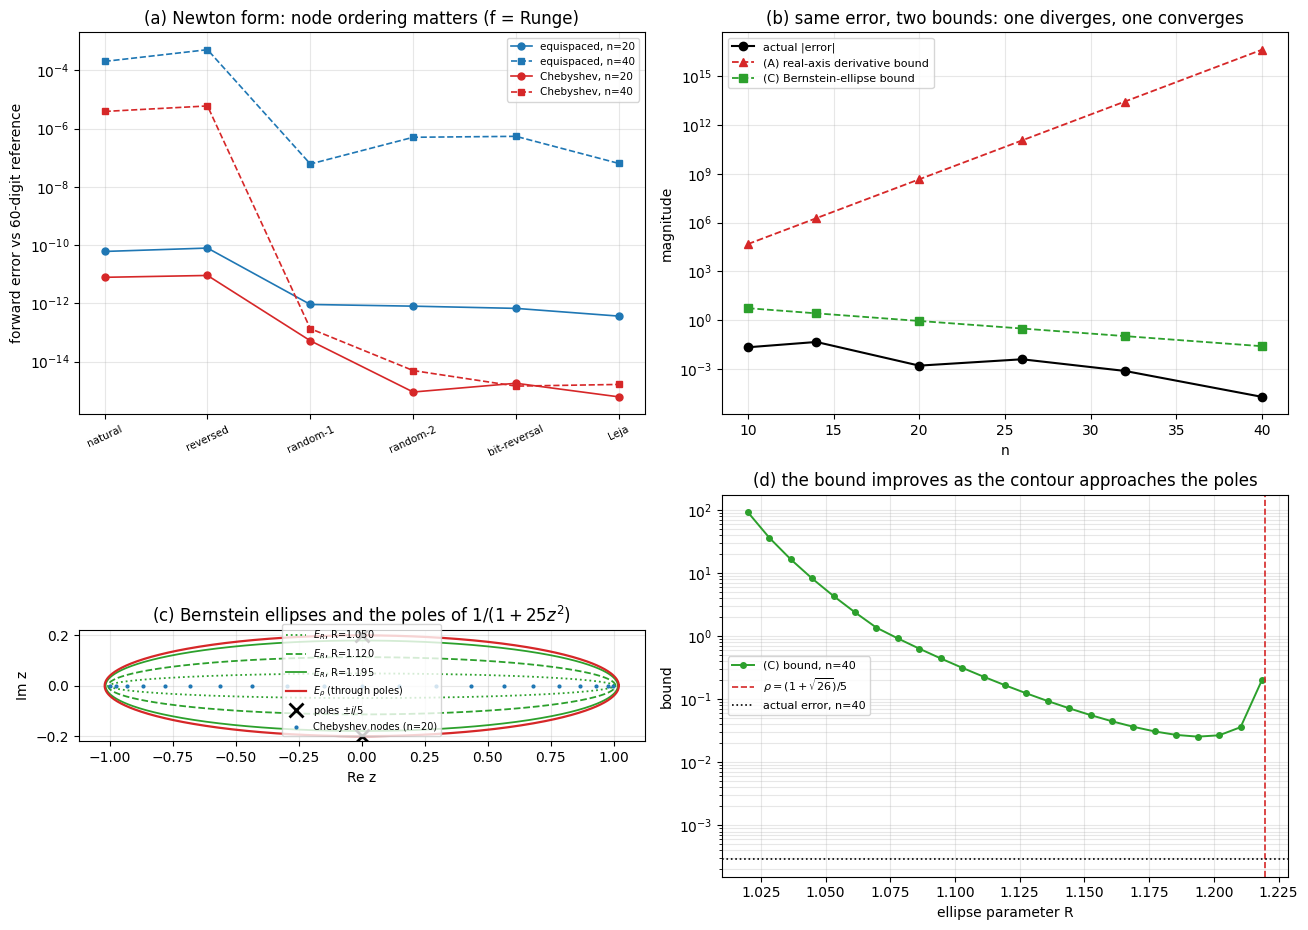

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [6]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 2, figsize=(13.2, 9.4))

# (a) 순서별 전방오차
axA = ax[0,0]
sub = df1[(df1.f=="Runge")]
labels = list(sub.order.unique())
xpos = np.arange(len(labels))
for (fam, n), col, mk in zip([("equispaced",20),("equispaced",40),
                              ("Chebyshev",20),("Chebyshev",40)],
                             ("#1f77b4","#1f77b4","#d62728","#d62728"), ("o","s","o","s")):
    g = sub[(sub.nodes==fam)&(sub.n==n)].set_index("order").loc[labels]
    axA.semilogy(xpos, g.fwd_err, marker=mk, color=col, ms=5, lw=1.2,
                 ls="-" if n==20 else "--", label=f"{fam}, n={n}")
axA.set_xticks(xpos); axA.set_xticklabels(labels, rotation=25, fontsize=7.5)
axA.set_ylabel("forward error vs 60-digit reference")
axA.set_title("(a) Newton form: node ordering matters (f = Runge)")
axA.legend(fontsize=7.5); axA.grid(alpha=.3, which="both")

# (b) 세 표현
axB = ax[0,1]
axB.semilogy(df3.n, np.abs(df3.err_true), "o-", color="k", lw=1.5, label="actual |error|")
axB.semilogy(df3.n, df3.boundA, "^--", color="#d62728", lw=1.3, label="(A) real-axis derivative bound")
axB.semilogy(df3.n, df3.boundC, "s--", color="#2ca02c", lw=1.3, label="(C) Bernstein-ellipse bound")
axB.set_xlabel("n"); axB.set_ylabel("magnitude")
axB.set_title("(b) same error, two bounds: one diverges, one converges")
axB.legend(fontsize=8); axB.grid(alpha=.3, which="both")

# (c) 복소평면
axC = ax[1,0]
th = np.linspace(0, 2*np.pi, 600)
for R, sty in ((1.05, ":"), (1.12, "--"), (0.98*RHO, "-")):
    z = 0.5*(R*np.exp(1j*th) + np.exp(-1j*th)/R)
    axC.plot(z.real, z.imag, sty, color="#2ca02c", lw=1.3,
             label=f"$E_R$, R={R:.3f}")
zr = 0.5*(RHO*np.exp(1j*th) + np.exp(-1j*th)/RHO)
axC.plot(zr.real, zr.imag, "-", color="#d62728", lw=1.6, label=r"$E_\rho$ (through poles)")
axC.plot([0,0], [0.2,-0.2], "x", color="k", ms=10, mew=2, label=r"poles $\pm i/5$")
xs40p = cheb_roots(21)
axC.plot(xs40p, np.zeros_like(xs40p), ".", color="#1f77b4", ms=4, label="Chebyshev nodes (n=20)")
axC.set_xlabel("Re z"); axC.set_ylabel("Im z"); axC.set_aspect("equal")
axC.set_title(r"(c) Bernstein ellipses and the poles of $1/(1+25z^2)$")
axC.legend(fontsize=7); axC.grid(alpha=.3)

# (d) R 에 대한 상계
axD = ax[1,1]
axD.semilogy(Rs, bs, "o-", color="#2ca02c", lw=1.4, ms=4, label="(C) bound, n=40")
axD.axvline(RHO, color="#d62728", ls="--", lw=1.2, label=r"$\rho=(1+\sqrt{26})/5$")
axD.axhline(e40, color="k", ls=":", lw=1.2, label="actual error, n=40")
axD.set_xlabel("ellipse parameter R"); axD.set_ylabel("bound")
axD.set_title("(d) the bound improves as the contour approaches the poles")
axD.legend(fontsize=8); axD.grid(alpha=.3, which="both")

plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **[a] — 먼저 잘못된 지표를 걸러낸다.** $\max_k|c_k|$ 는 Runge 함수에서 **모든 순서에 대해
   같은 값**이 나온다. 우연이 아니다: 최고차 계수 $f[x_0,\dots,x_n]$ 은 순서에 무관하고
   (그것이 다항식의 최고차 계수이므로), Runge 에서는 그 값이 나머지 $c_k$ 를 압도한다.
   순서 진단으로는 **중첩곱의 항 크기** $\max_k|c_k|\max_x\prod_{j<k}|x-x_j|$ ([a2]) 나
   소거비 ([b]) 를 써야 한다. — 지표를 고르는 일 자체가 이 문제의 절반이다.

2. **[a2]–[d] — 같은 다항식인데 절점 순서만 바꿔도 결과가 $10^{9}$ 배 달라진다.**
   Runge · Chebyshev · $n=40$ 에서 항 크기가 자연순 $4.0\times10^{10}$, Leja $1.09$ —
   **열 자리 차이**다. 소거비도 $5.1\times10^{13}$ 대 $3.7\times10^{9}$ 로 갈리고, 전방오차는
   자연순 $3.9\times10^{-6}$ 대 Leja $1.6\times10^{-15}$ 로 아홉 자리 갈린다. 자연순과 역순이
   가장 나쁜데, 이유가 같다: 부분곱 $\prod_{j<k}|x-x_j|$ 가 한쪽 끝에서 시작해 단조로 자라
   중간 항이 최종 결과보다 훨씬 커진다. **Leja 순서는 그 부분곱을 그리디하게 크게 유지해
   항 크기를 $O(1)$ 로 눌러 놓는다.**
   다만 Leja 가 **항상** 최선은 아니다 ([d] 의 `best` 열: 8 행 중 2 행). $e^{x}$ 처럼 계수가
   빠르게 감쇠하는 경우에는 자연순이 이미 충분히 좋고, bit-reversal 이나 무작위 순서가 근소하게
   이기기도 한다. 확실한 것은 **최악 (자연순·역순) 을 피하는 것**이고, Leja 는 항상 최악
   근처에 있지 않다 — 그것이 실무적 가치다. 그리고 순서의 영향은 **절점 배치가 나쁠수록
   커진다** (등간격 $n=40$ 에서 최악/최선 $8.4\times10^{3}$, Chebyshev $n=40$ 에서
   $4.2\times10^{9}$ — 후자가 더 큰 것은 Chebyshev 의 최선이 그만큼 좋기 때문이다).

3. **[e] — (B) 는 항등식이고, (C) 는 항등식을 수치적분한 것이다.** 나눗셈차분 형식
   $f[x_0,\dots,x_n,x]\,\omega(x)$ 는 실제 오차와 기계정밀도 수준에서 일치한다 (mpmath 로
   계산했을 때). Hermite 등고선적분도 사다리꼴 규칙의 **지수수렴** 덕분에 몇 자리까지 일치한다.
   즉 세 표현의 동치성이 수치로 확인된다. **그런데 (B) 는 예측력이 없다** — $f[x_0..x_n,x]$ 를
   알려면 $f(x)$ 를 알아야 하고, $f(x)$ 를 알면 오차를 직접 계산할 수 있다. (B) 의 가치는
   *계산*이 아니라 *구조* 다 (P2 가 보인 연속성·중복절점 확장).

4. **[f]·[h]·[k] — (A) 는 Runge 함수에서 무용하다. 그 무용함의 크기가 측정된다.**
   $\|f^{(n+1)}\|_\infty/(n+1)!\sim5^{n+1}$ 과 $\|\omega\|_\infty=2^{-n}$ 를 곱하면 상계가
   $2.5^{n}$ 로 발산한다 — 회귀로 잰 발산율이 이론 $2.5$ 와 맞는다. 실제 오차는 같은 $n$ 에서
   $\rho^{-n}$ 로 **수렴**하므로, $n=40$ 에서 (A) 는 실제의 $10^{19}$ 배를 넘는다.
   **"상계가 발산한다" 는 것은 수렴하지 않는다는 뜻이 아니라, 그 상계로는 아무것도 말할 수
   없다는 뜻이다.**

5. **[g] — 대조군: $f=e^{x}$ 에서는 (A) 가 훌륭하다.** $\|f^{(m)}\|_\infty=e$ 가 $m$ 에 대해
   유계이므로 $\min\|\omega\|=2^{-n}$ 의 이득이 그대로 살아나 상계 $e/(2^n(n+1)!)$ 가 실제
   오차의 $1.5$ 배 남짓이다. **(A) 의 성패를 가르는 것은 $f$ 의 매끄러움이 아니라
   $\|f^{(m)}\|_\infty/m!$ 의 증가율**이고, 그 증가율은 복소평면에서 가장 가까운 특이점까지의
   거리 $d$ 에 대해 $d^{-m}$ 이다. Runge 는 $d=1/5$, 지수함수는 $d=\infty$.

6. **[i] — Day 103 P3 이 측정만 했던 $\rho$ 가 여기서 유도된다.** 실측 감쇠율이 닫힌 형태
   $\rho=(1+\sqrt{26})/5=1.2198039$ 와 소수점 셋째 자리까지 맞고, 지수적합 $R^2$ 가 $1$ 에
   가깝다. 그리고 그 $\rho$ 는 **극점 $\pm i/5$ 를 지나는 Bernstein 타원**의 파라미터일 뿐이다:
   $R-R^{-1}=2\cdot\tfrac15$. Day 103 P3 의 노트가 "확인만 했다" 고 적었던 것을 오늘 유도로
   바꿨다.

7. **[j]·[j2] — 최적 등고선은 극점에 "붙지 않는다" (예상과 반대).** 처음 예상은 $R^\star$ 가
   탐색 상한 $0.999\rho$ 에 붙으리라는 것이었으나, $n=40$ 의 실제 최적은 $R^\star=1.1938$ 로
   **내부**에 있다. 두 효과가 겨루기 때문이다: $|\omega(z)|^{-1}\sim R^{-(n+1)}$ 의 이득과
   $|f(z)|\sim 1/\mathrm{dist}$ 의 손해. 그런데 $n$ 을 키우면 전자가 커지므로 $R^\star$ 가
   $\rho$ 로 밀려 올라가고, 측정된 간격이 $\rho-R^\star\sim n^{-0.73}$ 로 줄어든다.
   **그래서 "수렴률은 $\sup_{R<\rho}$ 로 주어진다" 는 진술은 $n\to\infty$ 의 극한에서만
   정확하다** — 유한한 $n$ 에서는 상수 $C(R)$ 이 $R\to\rho$ 에서 발산하므로 내부 최적이
   존재하고, 그 사실이 [i] 에서 $(C)$ 상계/실제 오차 비가 $50\to133$ 으로 **천천히 커지는**
   이유이기도 하다 (고정된 $R=0.98\rho$ 를 썼으므로 큰 $n$ 에서는 최적이 아니다).

> **결론**: 오차의 세 표현은 동치이지만 **예측력의 서열이 있다.**
> (A) 실축 도함수 형태는 $\|f^{(m)}\|/m!$ 가 유계인 함수 (전해석) 에서만 쓸모 있고,
> (B) 나눗셈차분 형태는 항등식이라 예측이 아니라 구조를 주며,
> (C) 등고선 형태만이 **특이점의 위치를 수렴률로 번역**한다:
> $$\|f-p_n\|_\infty \lesssim C\rho^{-n},\qquad \rho=\text{극점을 지나는 Bernstein 타원 파라미터}.$$
> Runge 함수에서 (A) 는 $2.5^{n}$ 로 발산하고 (C) 는 $1.2198^{-n}$ 로 수렴한다 — 같은 오차에
> 대한 두 상계가 $n=40$ 에서 $10^{19}$ 배 넘게 갈린다. **§4.2 의 교훈은 "오차식을 안다" 가
> 아니라 "어느 오차식을 쓰느냐" 이다.**

**다음 단원으로의 연결.** 오늘 세 노트북이 확립한 것을 정리하면: $\xi_x$ 는 실재하지만 함수가
아니고 (P1), 나눗셈차분이 그 자리를 대신하며 중복절점까지 확장되고 (P2), 수렴률을 정하는 것은
복소평면의 특이점이다 (P3). **§4.3 은 이 오차식을 미분에 적용한다** — 보간 다항식을 미분해
도함수를 근사하면 오차식이 어떻게 바뀌는지, 그리고 그 근사를 **Richardson 외삽**으로
가속하는 방법. 오늘 [d] 에서 본 "절단오차 $O(h)$ 대 소거 $O(\epsilon/h^{n})$ 의 U 자" 가
그 단원의 중심 주제가 된다.